In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from my_nn import activations, loss, metrics, nn
from my_nn.data.sample_data import generate_data, plot_data

In [2]:
# first get the data
data, targets = generate_data(seed=42)

#### For this notebook we will be looking at the binary classification using the target defined by the parabolic boundary.

In [3]:
# set up X, y for training
# use numpy arrays here for now so train test split works properly
X = np.array(data[["x1","x2"]])
y = np.array(data["binary_parabola"])
data_used = data[["x1","x2","binary_parabola"]].copy()

In [4]:
# do a train_test split
X_train, X_test, y_train, y_test = nn.train_test_split(X, y, test_size = 0.2, random_state=42)

In [5]:
# create 3 versions of the model to train. These will be identical here, and will only differ in how the .fit() is called
model_sgd = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 1, activation="sigmoid")
)

model_momentum = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 1, activation="sigmoid")
)

model_adam = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 1, activation="sigmoid")
)

In [6]:
# train the models
history_sgd = model_sgd.fit(
    X_train,
    y_train,
    epochs=200,
    learning_rate=0.01,
    batch_size=32,
    verbose=False,
    loss_fn="binary_cross_entropy",
    metric="accuracy",
    val_size = 0.2,
    optimizer="sgd"
)

Epoch 1 complete. Average Loss: 0.6490 , accuracy 0.7898 -  Validation Loss: 0.3870, Validation accuracy 0.7887
Epoch 2 complete. Average Loss: 0.3590 , accuracy 0.7981 -  Validation Loss: 0.3438, Validation accuracy 0.7900
Epoch 3 complete. Average Loss: 0.3294 , accuracy 0.8214 -  Validation Loss: 0.3235, Validation accuracy 0.8119
Epoch 4 complete. Average Loss: 0.3127 , accuracy 0.8481 -  Validation Loss: 0.3100, Validation accuracy 0.8394
Epoch 5 complete. Average Loss: 0.3011 , accuracy 0.8686 -  Validation Loss: 0.3002, Validation accuracy 0.8556
Epoch 6 complete. Average Loss: 0.2923 , accuracy 0.8805 -  Validation Loss: 0.2927, Validation accuracy 0.8675
Epoch 7 complete. Average Loss: 0.2851 , accuracy 0.8936 -  Validation Loss: 0.2863, Validation accuracy 0.8812
Epoch 8 complete. Average Loss: 0.2790 , accuracy 0.9006 -  Validation Loss: 0.2808, Validation accuracy 0.8875
Epoch 9 complete. Average Loss: 0.2737 , accuracy 0.9022 -  Validation Loss: 0.2762, Validation accuracy

In [7]:
history_momentum = model_momentum.fit(
    X_train,
    y_train,
    epochs=200,
    learning_rate=0.01,
    batch_size=32,
    verbose=False,
    loss_fn="binary_cross_entropy",
    metric="accuracy",
    val_size = 0.2,
    optimizer="momentum"
)

Epoch 1 complete. Average Loss: 0.5398 , accuracy 0.8992 -  Validation Loss: 0.3455, Validation accuracy 0.9025
Epoch 2 complete. Average Loss: 0.3258 , accuracy 0.8912 -  Validation Loss: 0.3022, Validation accuracy 0.8919
Epoch 3 complete. Average Loss: 0.2944 , accuracy 0.8958 -  Validation Loss: 0.2793, Validation accuracy 0.8969
Epoch 4 complete. Average Loss: 0.2739 , accuracy 0.9008 -  Validation Loss: 0.2628, Validation accuracy 0.9012
Epoch 5 complete. Average Loss: 0.2587 , accuracy 0.9017 -  Validation Loss: 0.2502, Validation accuracy 0.9012
Epoch 6 complete. Average Loss: 0.2470 , accuracy 0.9025 -  Validation Loss: 0.2404, Validation accuracy 0.9019
Epoch 7 complete. Average Loss: 0.2377 , accuracy 0.9033 -  Validation Loss: 0.2323, Validation accuracy 0.9038
Epoch 8 complete. Average Loss: 0.2303 , accuracy 0.9023 -  Validation Loss: 0.2259, Validation accuracy 0.9044
Epoch 9 complete. Average Loss: 0.2242 , accuracy 0.9019 -  Validation Loss: 0.2206, Validation accuracy

In [8]:
history_adam = model_adam.fit(
    X_train,
    y_train,
    epochs=200,
    learning_rate=0.01,
    batch_size=32,
    verbose=False,
    loss_fn="binary_cross_entropy",
    metric="accuracy",
    val_size = 0.2,
    optimizer="adam"
)

Epoch 1 complete. Average Loss: 0.1165 , accuracy 0.9800 -  Validation Loss: 0.0488, Validation accuracy 0.9788
Epoch 2 complete. Average Loss: 0.0429 , accuracy 0.9922 -  Validation Loss: 0.0256, Validation accuracy 0.9912
Epoch 3 complete. Average Loss: 0.0338 , accuracy 0.9819 -  Validation Loss: 0.0400, Validation accuracy 0.9794
Epoch 4 complete. Average Loss: 0.0295 , accuracy 0.9852 -  Validation Loss: 0.0239, Validation accuracy 0.9881
Epoch 5 complete. Average Loss: 0.0293 , accuracy 0.9942 -  Validation Loss: 0.0176, Validation accuracy 0.9944
Epoch 6 complete. Average Loss: 0.0257 , accuracy 0.9812 -  Validation Loss: 0.0468, Validation accuracy 0.9800
Epoch 7 complete. Average Loss: 0.0365 , accuracy 0.9925 -  Validation Loss: 0.0203, Validation accuracy 0.9919
Epoch 8 complete. Average Loss: 0.0240 , accuracy 0.9883 -  Validation Loss: 0.0255, Validation accuracy 0.9888
Epoch 9 complete. Average Loss: 0.0168 , accuracy 0.9942 -  Validation Loss: 0.0137, Validation accuracy

#### Let's look at the histories of each

##### First for standard gradient descent

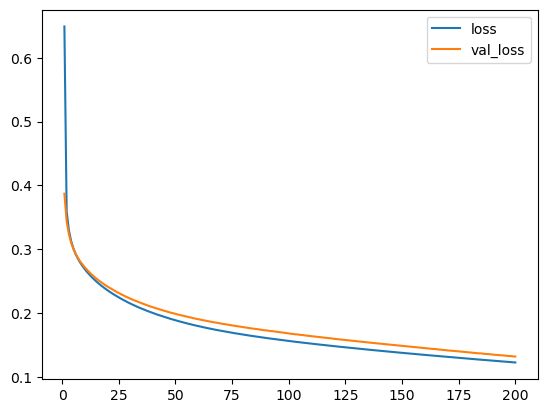

In [9]:
nn.plot_history(history_sgd, "loss", "val_loss")

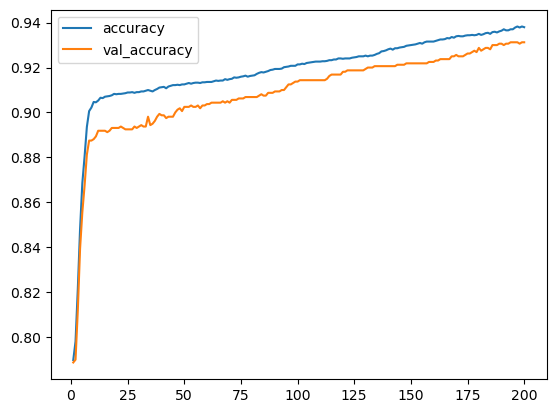

In [10]:
nn.plot_history(history_sgd, "accuracy", "val_accuracy")

##### Next for momentum

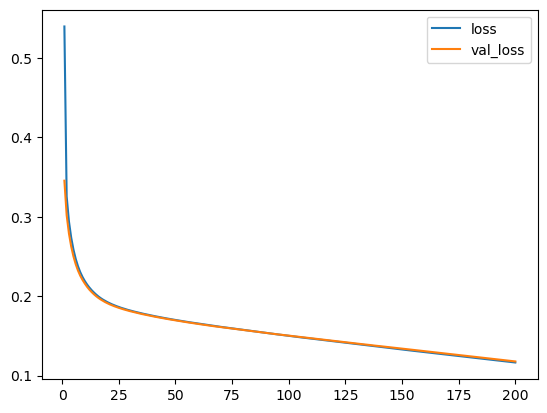

In [11]:
nn.plot_history(history_momentum, "loss", "val_loss")

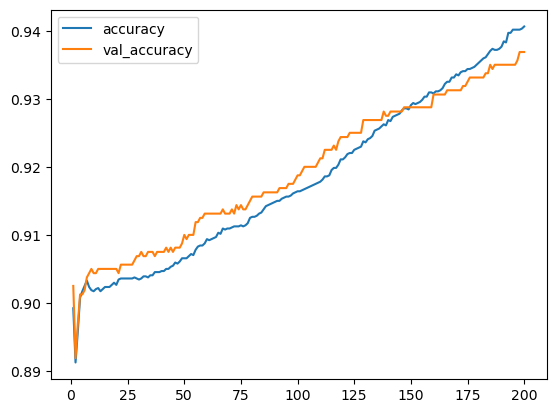

In [12]:
nn.plot_history(history_momentum, "accuracy", "val_accuracy")

In [13]:
##### Finally for adam

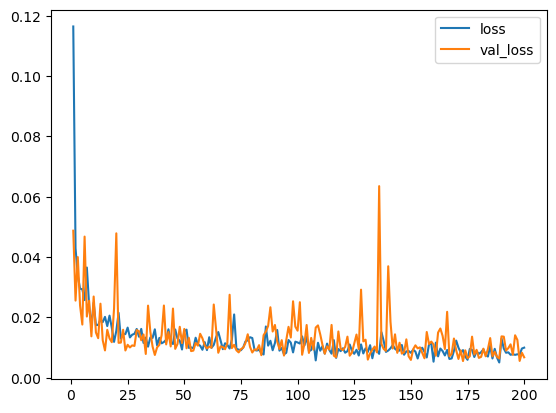

In [14]:
nn.plot_history(history_adam, "loss", "val_loss")

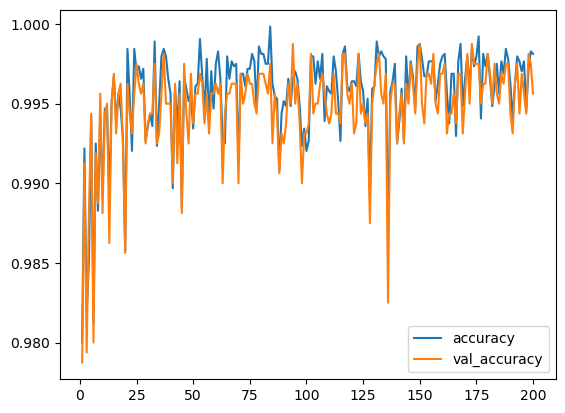

In [15]:
nn.plot_history(history_adam, "accuracy", "val_accuracy")

#### Now lets see how these do on the unseen test data

In [16]:
y_pred_sgd = model_sgd.predict(X_test)
y_pred_momentum = model_momentum.predict(X_test)
y_pred_adam = model_adam.predict(X_test)

In [17]:
print("SGD all real numbers: ", np.isfinite(y_pred_sgd).all())
print("Momentum all real numbers: ",np.isfinite(y_pred_momentum).all())
print("Adam all real numbers: ", np.isfinite(y_pred_adam).all())

SGD all real numbers:  True
Momentum all real numbers:  True
Adam all real numbers:  True


In [18]:
# convert to 0,1 for use in metrics
y_labels_sgd = (y_pred_sgd >= 0.5).astype(int)
y_labels_momentum = (y_pred_momentum>=0.5).astype(int)
y_labels_adam = (y_pred_adam>=0.5).astype(int)

In [19]:
acc_sgd = metrics.accuracy(y_test, y_labels_sgd)
acc_mom = metrics.accuracy(y_test, y_labels_momentum)
acc_adam = metrics.accuracy(y_test, y_labels_adam)

precision_sgd = metrics.precision(y_test, y_labels_sgd)
precision_mom = metrics.precision(y_test, y_labels_momentum)
precision_adam = metrics.precision(y_test, y_labels_adam)

recall_sgd = metrics.recall(y_test, y_labels_sgd)
recall_mom = metrics.recall(y_test, y_labels_momentum)
recall_adam = metrics.recall(y_test, y_labels_adam)

f1_sgd = metrics.f1_score(y_test, y_labels_sgd)
f1_mom = metrics.f1_score(y_test, y_labels_momentum)
f1_adam = metrics.f1_score(y_test, y_labels_adam)

spec_sgd = metrics.specificity(y_test, y_labels_sgd)
spec_mom = metrics.specificity(y_test, y_labels_momentum)
spec_adam = metrics.specificity(y_test, y_labels_adam)

bal_acc_sgd = metrics.balanced_accuracy(y_test, y_labels_sgd)
bal_acc_mom = metrics.balanced_accuracy(y_test, y_labels_momentum)
bal_acc_adam = metrics.balanced_accuracy(y_test, y_labels_adam)

In [20]:
print("For Standard Gradient Descent")
print("-----------------------------")
print(f"Accuracy: {acc_sgd: .4f}")
print(f"Precision: {precision_sgd: .4f}")
print(f"Recall: {recall_sgd: .4f}")
print(f"F1 Score: {f1_sgd: .4f}")
print(f"Specificity: {spec_sgd: .4f}")
print(f"Balanced Accuracy: {bal_acc_sgd: .4f}")

For Standard Gradient Descent
-----------------------------
Accuracy:  0.9375
Precision:  0.7795
Recall:  0.9682
F1 Score:  0.8637
Specificity:  0.9296
Balanced Accuracy:  0.9489


In [21]:
print("For using momentum")
print("-----------------------------")
print(f"Accuracy: {acc_mom: .4f}")
print(f"Precision: {precision_mom: .4f}")
print(f"Recall: {recall_mom: .4f}")
print(f"F1 Score: {f1_mom: .4f}")
print(f"Specificity: {spec_mom: .4f}")
print(f"Balanced Accuracy: {bal_acc_mom: .4f}")

For using momentum
-----------------------------
Accuracy:  0.9435
Precision:  0.7953
Recall:  0.9782
F1 Score:  0.8773
Specificity:  0.9345
Balanced Accuracy:  0.9563


In [22]:
print("For Adam optimization")
print("-----------------------------")
print(f"Accuracy: {acc_adam: .4f}")
print(f"Precision: {precision_adam: .4f}")
print(f"Recall: {recall_adam: .4f}")
print(f"F1 Score: {f1_adam: .4f}")
print(f"Specificity: {spec_adam: .4f}")
print(f"Balanced Accuracy: {bal_acc_adam: .4f}")

For Adam optimization
-----------------------------
Accuracy:  0.9960
Precision:  0.9941
Recall:  0.9902
F1 Score:  0.9921
Specificity:  0.9980
Balanced Accuracy:  0.9941


#### Lastly we look at visualizing how the model does on the whole space for each version. All will show the true decision boundary and scatterplot the points, coloring by prediction.

In [23]:
y_pred_sgd = (model_sgd.predict(X) >= 0.5).astype(int)
y_pred_mom = (model_momentum.predict(X) >= 0.5).astype(int)
y_pred_adam = (model_adam.predict(X) >= 0.5).astype(int)

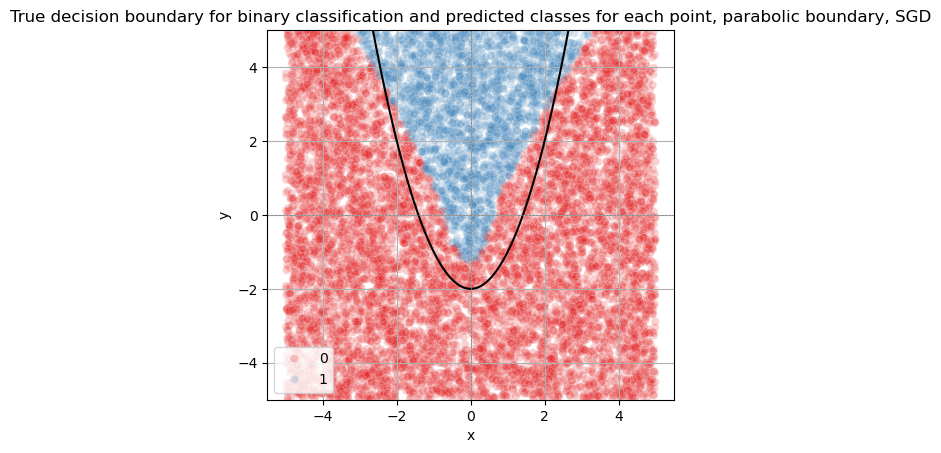

In [24]:
x = np.linspace(-5, 5, 400)
y = x**2 - 2
plt.plot(x, y, color='k', linestyle='solid')
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_pred_sgd.ravel(), palette='Set1', alpha=0.2)

# Add labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title("True decision boundary for binary classification and predicted classes for each point, parabolic boundary, SGD")
plt.grid(True)
plt.ylim(-5,5)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box') # Ensure proper aspect ratio
plt.show()

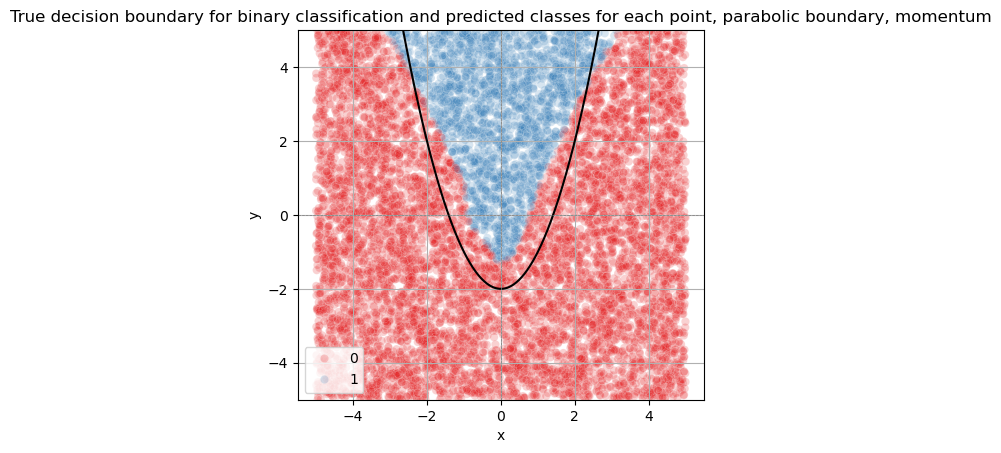

In [25]:
x = np.linspace(-5, 5, 400)
y = x**2 - 2
plt.plot(x, y, color='k', linestyle='solid')
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_pred_mom.ravel(), palette='Set1', alpha=0.2)

# Add labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title("True decision boundary for binary classification and predicted classes for each point, parabolic boundary, momentum")
plt.grid(True)
plt.ylim(-5,5)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box') # Ensure proper aspect ratio
plt.show()

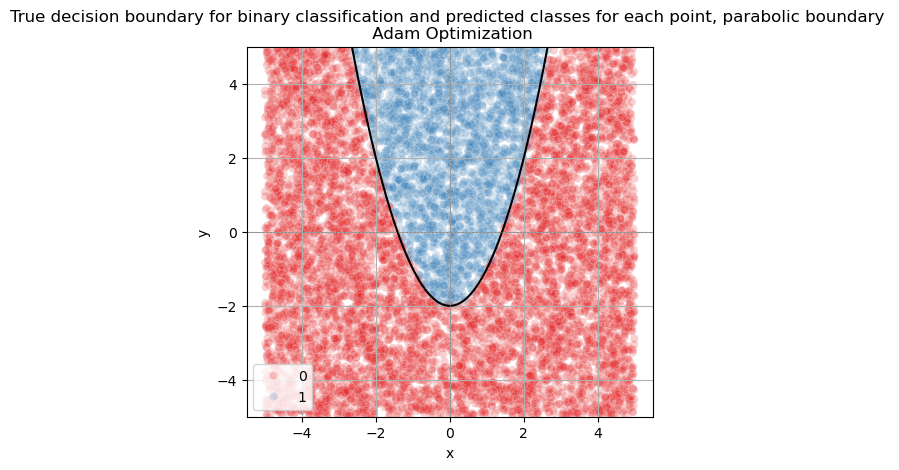

In [26]:
x = np.linspace(-5, 5, 400)
y = x**2 - 2
plt.plot(x, y, color='k', linestyle='solid')
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_pred_adam.ravel(), palette='Set1', alpha=0.2)

# Add labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title("True decision boundary for binary classification and predicted classes for each point, parabolic boundary \n Adam Optimization")
plt.grid(True)
plt.ylim(-5,5)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box') # Ensure proper aspect ratio
plt.show()